<a href="https://colab.research.google.com/github/ChiaraTagiullo/olympic-power-structure/blob/main/Specialization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Olympic Power Structure — Specialization

## Goal

Analyze whether countries dominate across all sports or specialize in specific disciplines.

Main question:
Do countries win medals broadly, or do they focus on specific sports?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import os

pd.set_option("display.max_columns", None)

## 1. Upload the raw Olympic dataset

To analyze specialization, I need sport-level information.
Therefore, I use the original athlete-event dataset.

In [2]:
uploaded = files.upload()

Saving ds proj.xlsx to ds proj.xlsx


In [3]:
print(os.listdir())

['.config', 'ds proj.xlsx', 'sample_data']


In [4]:
df = pd.read_excel("ds proj.xlsx", sheet_name="athlete_events")
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


## 2. Keep only medal-winning observations

In [5]:
medals = df[df["Medal"].notna()].copy()
medals.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
37,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze
38,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze
40,16,Juhamatti Tapio Aaltonen,M,28.0,184.0,85.0,Finland,FIN,2014 Winter,2014,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze
41,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze


## 3. Remove duplicates (team events)

As in previous steps, I remove duplicates to avoid counting multiple athletes for the same medal.

In [6]:
medals_unique = medals.drop_duplicates(
    subset=["NOC", "Year", "Sport", "Event", "Medal"]
).copy()

medals_unique.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
37,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze
38,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze
40,16,Juhamatti Tapio Aaltonen,M,28.0,184.0,85.0,Finland,FIN,2014 Winter,2014,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze
41,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze


## 4. Build country-sport medal table

In [7]:
country_sport = (
    medals_unique
    .groupby(["NOC", "Sport"])
    .size()
    .reset_index(name="Medals")
)

country_sport.head()

,NOC,Sport,Medals
0,AFG,Taekwondo,2
1,AHO,Sailing,1
2,ALG,Athletics,9
3,ALG,Boxing,6
4,ALG,Judo,2


## 5. Create pivot table (countries × sports)

In [8]:
pivot = country_sport.pivot(index="NOC", columns="Sport", values="Medals").fillna(0)
pivot.head()

Sport,Aeronautics,Alpine Skiing,Alpinism,Archery,Art Competitions,Athletics,Badminton,Baseball,Basketball,Basque Pelota,Beach Volleyball,Biathlon,Bobsleigh,Boxing,Canoeing,Cricket,Croquet,Cross Country Skiing,Curling,Cycling,Diving,Equestrianism,Fencing,Figure Skating,Football,Freestyle Skiing,Golf,Gymnastics,Handball,Hockey,Ice Hockey,Jeu De Paume,Judo,Lacrosse,Luge,Military Ski Patrol,Modern Pentathlon,Motorboating,Nordic Combined,Polo,Racquets,Rhythmic Gymnastics,Roque,Rowing,Rugby,Rugby Sevens,Sailing,Shooting,Short Track Speed Skating,Skeleton,Ski Jumping,Snowboarding,Softball,Speed Skating,Swimming,Synchronized Swimming,Table Tennis,Taekwondo,Tennis,Trampolining,Triathlon,Tug-Of-War,Volleyball,Water Polo,Weightlifting,Wrestling
NOC,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AFG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AHO,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ALG,0.0,0.0,0.0,0.0,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ANZ,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ARG,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,24.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,4.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,4.0,0.0,0.0,10.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,1.0,5.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0


In [9]:
top_countries = (
    country_sport.groupby("NOC")["Medals"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

pivot_top = pivot.loc[top_countries]
pivot_top

Sport,Aeronautics,Alpine Skiing,Alpinism,Archery,Art Competitions,Athletics,Badminton,Baseball,Basketball,Basque Pelota,Beach Volleyball,Biathlon,Bobsleigh,Boxing,Canoeing,Cricket,Croquet,Cross Country Skiing,Curling,Cycling,Diving,Equestrianism,Fencing,Figure Skating,Football,Freestyle Skiing,Golf,Gymnastics,Handball,Hockey,Ice Hockey,Jeu De Paume,Judo,Lacrosse,Luge,Military Ski Patrol,Modern Pentathlon,Motorboating,Nordic Combined,Polo,Racquets,Rhythmic Gymnastics,Roque,Rowing,Rugby,Rugby Sevens,Sailing,Shooting,Short Track Speed Skating,Skeleton,Ski Jumping,Snowboarding,Softball,Speed Skating,Swimming,Synchronized Swimming,Table Tennis,Taekwondo,Tennis,Trampolining,Triathlon,Tug-Of-War,Volleyball,Water Polo,Weightlifting,Wrestling
NOC,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
USA,0.0,44.0,0.0,33.0,9.0,816.0,0.0,3.0,28.0,0.0,10.0,0.0,24.0,113.0,16.0,0.0,0.0,1.0,1.0,57.0,135.0,52.0,32.0,49.0,7.0,21.0,10.0,113.0,0.0,2.0,16.0,1.0,14.0,1.0,5.0,0.0,9.0,0.0,4.0,5.0,0.0,0.0,3.0,89.0,3.0,0.0,61.0,110.0,19.0,8.0,1.0,24.0,4.0,64.0,550.0,9.0,0.0,9.0,39.0,0.0,2.0,3.0,10.0,14.0,42.0,128.0
URS,0.0,1.0,0.0,7.0,0.0,193.0,0.0,0.0,12.0,0.0,0.0,19.0,3.0,51.0,51.0,0.0,0.0,68.0,0.0,24.0,14.0,15.0,49.0,24.0,5.0,0.0,0.0,179.0,6.0,2.0,9.0,0.0,21.0,0.0,6.0,0.0,15.0,0.0,3.0,0.0,0.0,2.0,0.0,42.0,0.0,0.0,12.0,49.0,0.0,0.0,1.0,0.0,0.0,58.0,59.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,7.0,62.0,116.0
GER,0.0,31.0,1.0,3.0,24.0,112.0,0.0,0.0,0.0,0.0,3.0,45.0,21.0,29.0,81.0,0.0,0.0,15.0,0.0,54.0,26.0,66.0,29.0,11.0,6.0,1.0,0.0,40.0,3.0,11.0,1.0,0.0,20.0,0.0,36.0,0.0,3.0,0.0,11.0,0.0,0.0,0.0,0.0,59.0,1.0,0.0,15.0,26.0,0.0,2.0,11.0,5.0,0.0,40.0,74.0,0.0,7.0,2.0,11.0,2.0,2.0,2.0,0.0,3.0,24.0,35.0
GBR,0.0,0.0,1.0,9.0,9.0,212.0,3.0,0.0,0.0,0.0,0.0,0.0,4.0,56.0,17.0,2.0,0.0,0.0,4.0,93.0,10.0,35.0,10.0,15.0,5.0,0.0,3.0,14.0,0.0,11.0,2.0,2.0,19.0,1.0,0.0,0.0,7.0,2.0,0.0,8.0,6.0,0.0,0.0,68.0,2.0,1.0,59.0,50.0,1.0,6.0,0.0,1.0,0.0,0.0,79.0,0.0,0.0,6.0,46.0,1.0,5.0,5.0,0.0,5.0,7.0,17.0
FRA,0.0,45.0,0.0,25.0,13.0,70.0,0.0,0.0,3.0,0.0,0.0,20.0,1.0,25.0,36.0,1.0,7.0,2.0,1.0,98.0,1.0,42.0,123.0,12.0,3.0,12.0,0.0,25.0,5.0,0.0,0.0,0.0,49.0,0.0,0.0,1.0,3.0,1.0,4.0,2.0,0.0,0.0,0.0,40.0,3.0,0.0,39.0,41.0,0.0,0.0,1.0,10.0,0.0,0.0,43.0,1.0,2.0,7.0,25.0,0.0,0.0,1.0,0.0,3.0,16.0,17.0
ITA,0.0,30.0,0.0,7.0,14.0,60.0,0.0,0.0,2.0,0.0,1.0,4.0,12.0,47.0,16.0,0.0,0.0,34.0,0.0,63.0,11.0,23.0,127.0,2.0,3.0,0.0,0.0,31.0,0.0,0.0,0.0,0.0,15.0,0.0,17.0,0.0,7.0,0.0,1.0,0.0,0.0,2.0,0.0,44.0,0.0,0.0,14.0,43.0,8.0,1.0,0.0,2.0,0.0,3.0,22.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,6.0,10.0,15.0,21.0
SWE,0.0,16.0,0.0,2.0,4.0,92.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,11.0,30.0,0.0,0.0,74.0,6.0,17.0,21.0,43.0,7.0,10.0,4.0,2.0,1.0,8.0,4.0,0.0,11.0,0.0,0.0,0.0,0.0,0.0,21.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,35.0,59.0,0.0,0.0,2.0,1.0,0.0,16.0,38.0,0.0,3.0,0.0,8.0,0.0,1.0,3.0,0.0,3.0,4.0,86.0
CHN,0.0,0.0,0.0,9.0,0.0,27.0,40.0,0.0,2.0,0.0,2.0,0.0,0.0,12.0,2.0,0.0,0.0,0.0,1.0,7.0,69.0,0.0,14.0,7.0,1.0,8.0,1.0,61.0,1.0,1.0,0.0,0.0,22.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,0.0,0.0,6.0,56.0,30.0,0.0,0.0,0.0,1.0,7.0,43.0,5.0,53.0,10.0,2.0,11.0,0.0,0.0,6.0,0.0,57.0,10.0
RUS,0.0,1.0,0.0,2.0,0.0,77.0,1.0,0.0,3.0,0.0,0.0,24.0,4.0,30.0,13.0,0.0,0.0,33.0,0.0,19.0,18.0,0.0,26.0,27.0,0.0,4.0,0.0,44.0,4.0,0.0,2.0,0.0,16.0,0.0,3.0,0.0,5.0,0.0,1.0,0.0,0.0,16.0,0.0,4.0,0.0,0.0,3.0,33.0,5.0,3.0,0.0,5.0,0.0,13.0,23.0,10.0,0.0,4.0,8.0,4.0,0.0,0.0,6.0,4.0,26.0,60.0


## 6. Normalize by country

To identify specialization, I normalize medal counts so that each row sums to 1.

This allows comparison of relative focus across sports.

In [10]:
pivot_norm = pivot_top.div(pivot_top.sum(axis=1), axis=0)
pivot_norm.head()

Sport,Aeronautics,Alpine Skiing,Alpinism,Archery,Art Competitions,Athletics,Badminton,Baseball,Basketball,Basque Pelota,Beach Volleyball,Biathlon,Bobsleigh,Boxing,Canoeing,Cricket,Croquet,Cross Country Skiing,Curling,Cycling,Diving,Equestrianism,Fencing,Figure Skating,Football,Freestyle Skiing,Golf,Gymnastics,Handball,Hockey,Ice Hockey,Jeu De Paume,Judo,Lacrosse,Luge,Military Ski Patrol,Modern Pentathlon,Motorboating,Nordic Combined,Polo,Racquets,Rhythmic Gymnastics,Roque,Rowing,Rugby,Rugby Sevens,Sailing,Shooting,Short Track Speed Skating,Skeleton,Ski Jumping,Snowboarding,Softball,Speed Skating,Swimming,Synchronized Swimming,Table Tennis,Taekwondo,Tennis,Trampolining,Triathlon,Tug-Of-War,Volleyball,Water Polo,Weightlifting,Wrestling
NOC,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
USA,0.0,0.015586,0.000000,0.011690,0.003188,0.289054,0.000000,0.001063,0.009919,0.0,0.003542,0.000000,0.008502,0.040028,0.005668,0.000000,0.000000,0.000354,0.000354,0.020191,0.047821,0.018420,0.011335,0.017357,0.002480,0.007439,0.003542,0.040028,0.000000,0.000708,0.005668,0.000354,0.004959,0.000354,0.001771,0.000000,0.003188,0.000000,0.001417,0.001771,0.000000,0.000000,0.001063,0.031527,0.001063,0.000000,0.021608,0.038966,0.006730,0.002834,0.000354,0.008502,0.001417,0.022671,0.194828,0.003188,0.000000,0.003188,0.013815,0.000000,0.000708,0.001063,0.003542,0.004959,0.014878,0.045342
URS,0.0,0.000835,0.000000,0.005848,0.000000,0.161236,0.000000,0.000000,0.010025,0.0,0.000000,0.015873,0.002506,0.042607,0.042607,0.000000,0.000000,0.056809,0.000000,0.020050,0.011696,0.012531,0.040936,0.020050,0.004177,0.000000,0.000000,0.149541,0.005013,0.001671,0.007519,0.000000,0.017544,0.000000,0.005013,0.000000,0.012531,0.000000,0.002506,0.000000,0.000000,0.001671,0.000000,0.035088,0.000000,0.000000,0.010025,0.040936,0.000000,0.000000,0.000835,0.000000,0.000000,0.048454,0.049290,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010025,0.005848,0.051796,0.096909
GER,0.0,0.030876,0.000996,0.002988,0.023904,0.111554,0.000000,0.000000,0.000000,0.0,0.002988,0.044821,0.020916,0.028884,0.080677,0.000000,0.000000,0.014940,0.000000,0.053785,0.025896,0.065737,0.028884,0.010956,0.005976,0.000996,0.000000,0.039841,0.002988,0.010956,0.000996,0.000000,0.019920,0.000000,0.035857,0.000000,0.002988,0.000000,0.010956,0.000000,0.000000,0.000000,0.000000,0.058765,0.000996,0.000000,0.014940,0.025896,0.000000,0.001992,0.010956,0.004980,0.000000,0.039841,0.073705,0.000000,0.006972,0.001992,0.010956,0.001992,0.001992,0.001992,0.000000,0.002988,0.023904,0.034861
GBR,0.0,0.000000,0.001088,0.009793,0.009793,0.230686,0.003264,0.000000,0.000000,0.0,0.000000,0.000000,0.004353,0.060936,0.018498,0.002176,0.000000,0.000000,0.004353,0.101197,0.010881,0.038085,0.010881,0.016322,0.005441,0.000000,0.003264,0.015234,0.000000,0.011970,0.002176,0.002176,0.020675,0.001088,0.000000,0.000000,0.007617,0.002176,0.000000,0.008705,0.006529,0.000000,0.000000,0.073993,0.002176,0.001088,0.064200,0.054407,0.001088,0.006529,0.000000,0.001088,0.000000,0.000000,0.085963,0.000000,0.000000,0.006529,0.050054,0.001088,0.005441,0.005441,0.000000,0.005441,0.007617,0.018498
FRA,0.0,0.051195,0.000000,0.028441,0.014790,0.079636,0.000000,0.000000,0.003413,0.0,0.000000,0.022753,0.001138,0.028441,0.040956,0.001138,0.007964,0.002275,0.001138,0.111490,0.001138,0.047782,0.139932,0.013652,0.003413,0.013652,0.000000,0.028441,0.005688,0.000000,0.000000,0.000000,0.055745,0.000000,0.000000,0.001138,0.003413,0.001138,0.004551,0.002275,0.000000,0.000000,0.000000,0.045506,0.003413,0.000000,0.044369,0.046644,0.000000,0.000000,0.001138,0.011377,0.000000,0.000000,0.048919,0.001138,0.002275,0.007964,0.028441,0.000000,0.000000,0.001138,0.000000,0.003413,0.018203,0.019340


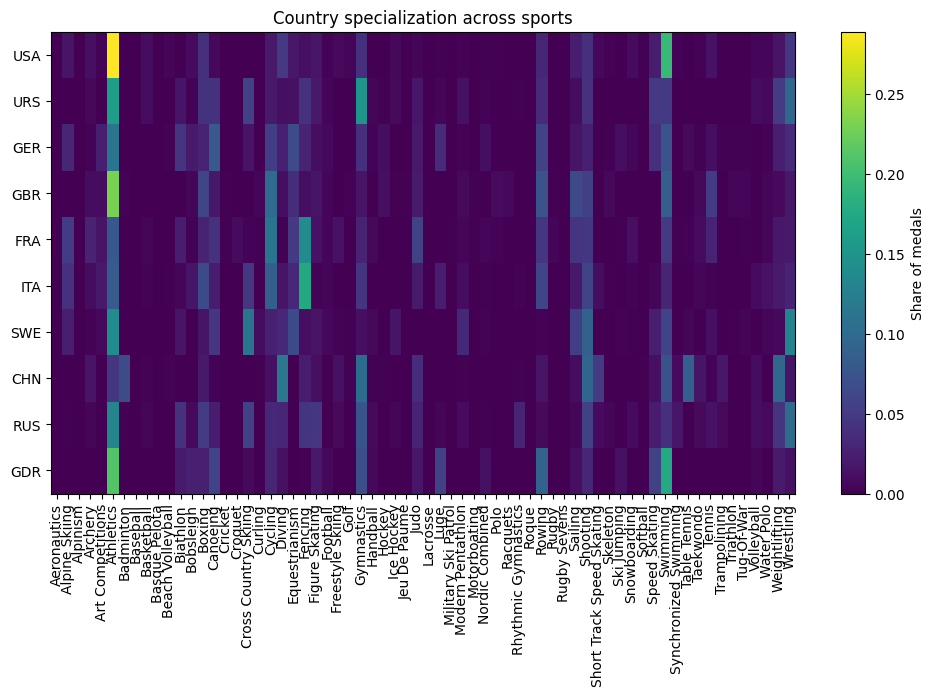

In [11]:
plt.figure(figsize=(12,6))
plt.imshow(pivot_norm, aspect='auto')

plt.colorbar(label="Share of medals")

plt.xticks(range(len(pivot_norm.columns)), pivot_norm.columns, rotation=90)
plt.yticks(range(len(pivot_norm.index)), pivot_norm.index)

plt.title("Country specialization across sports")
plt.show()

## Initial visualization of country-sport distribution

This first heatmap represents the distribution of medals across all sports for the top countries.

Each row corresponds to a country, and each column to a sport.

While this visualization provides a comprehensive overview, it is difficult to interpret due to the large number of sports included.

The high dimensionality makes it challenging to identify clear patterns or meaningful differences between countries.

To improve readability and highlight the most relevant structures, I focus on the top sports by total medal count in the next step.

In [14]:
top_sports_list = (
    country_sport.groupby("Sport")["Medals"]
    .sum()
    .sort_values(ascending=False)
    .head(12)
    .index
)

pivot_small = pivot_top[top_sports_list]

In [15]:
pivot_small_norm = pivot_small.div(pivot_small.sum(axis=1), axis=0)

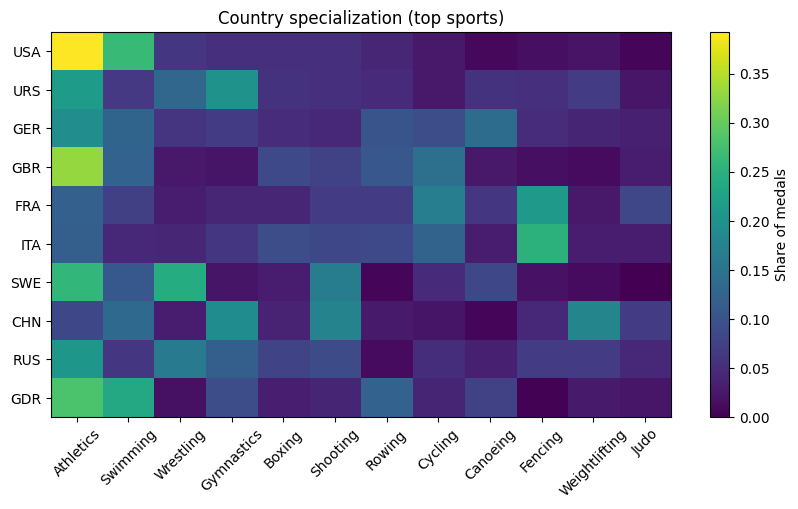

In [16]:
plt.figure(figsize=(10,5))
plt.imshow(pivot_small_norm, aspect='auto')

plt.colorbar(label="Share of medals")

plt.xticks(range(len(pivot_small_norm.columns)),
           pivot_small_norm.columns, rotation=45)

plt.yticks(range(len(pivot_small_norm.index)),
           pivot_small_norm.index)

plt.title("Country specialization (top sports)")
plt.show()

## Country specialization across major sports

By restricting the analysis to the top sports, the heatmap becomes much more interpretable.

Clear patterns of specialization emerge:

- The United States shows a strong concentration in athletics and swimming  
- China appears more specialized in technical and strength-based sports such as gymnastics and weightlifting  
- Italy stands out in fencing  
- Former Soviet countries (e.g. URS, RUS) show strengths in wrestling and other technical disciplines  
- Some countries display a more balanced distribution, while others are highly concentrated in a few sports  

These patterns indicate that countries do not dominate uniformly across all disciplines.

Instead, Olympic success is achieved through targeted specialization in specific sports.

This suggests that performance is shaped not only by economic resources, but also by strategic investment, historical tradition, and institutional focus within particular disciplines.